# Calculo de las medias y distribuciones del O3, NO y NO2

Datos combinados: 2400079 filas, 3 estaciones.
Medias diarias, estacionales y anuales guardadas.

=== MEDIAS TOTALES (todos los años y estaciones) ===
variable  media_total
      O3    64.597964
      NO     4.193090
     NO2    10.488689
Error al generar boxplots por estación: cannot reindex on an axis with duplicate labels


ValueError: cannot reindex on an axis with duplicate labels

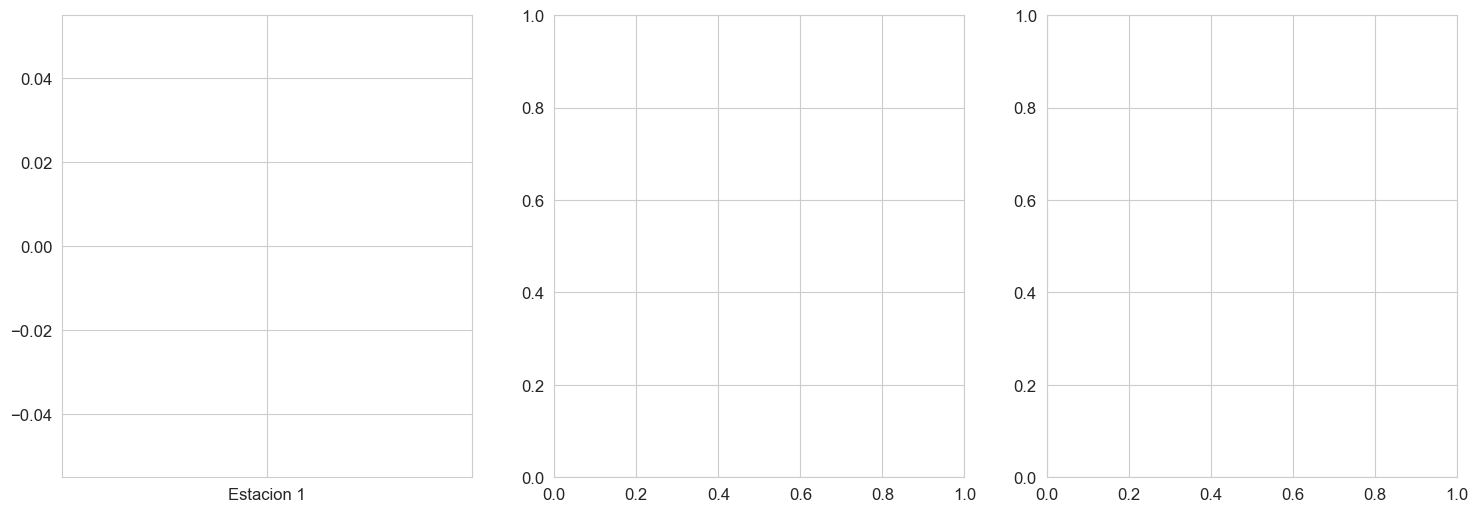

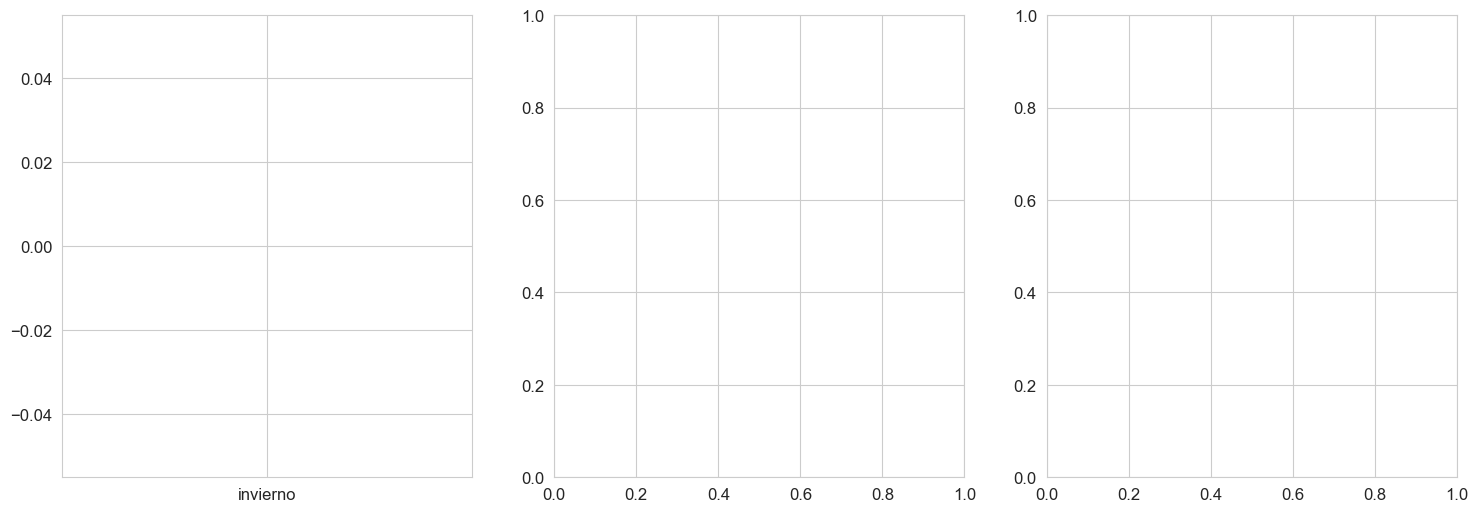

In [5]:
# Código 5: Medias diarias, estacionales, anuales y totales de O3, NO, NO2 + gráficos de distribución
# Dependencias: pandas, numpy, matplotlib, seaborn
# pip install pandas numpy matplotlib seaborn

import os
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# ---------------------------
# CONFIGURACIÓN
# ---------------------------
# Carpeta con archivos CSV (originales o imputados)
INPUT_DIR = os.path.expanduser("~/Documents/GitHub/TFGFinal/Datos TFG/DATOSFINALES/HORARIOS")
# Si prefieres usar la carpeta de imputados, cambia a:
# INPUT_DIR = os.path.expanduser("~/Documents/GitHub/TFGFinal/Datos_TFG_imputed_iterative")

OUTPUT_DIR = os.path.expanduser("~/Documents/GitHub/TFGFinal/analisis_temporal")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Columnas de interés
VAR_COLS = ['O3', 'NO', 'NO2']
# Mapeo de posibles nombres alternativos
COLUMN_MAPPING = {
    'O3_for_impute': 'O3',
    'O₃': 'O3',
    'Ozone': 'O3',
    'NO': 'NO',
    'NO2': 'NO2'
}

# ---------------------------
# 1. Cargar datos automáticamente
# ---------------------------
def load_all_stations_from_dir(directory):
    directory = Path(directory).expanduser()
    if not directory.exists():
        raise FileNotFoundError(f"La carpeta {directory} no existe.")
    csv_files = list(directory.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No se encontraron archivos CSV en {directory}.")
    
    dfs = []
    for f in csv_files:
        try:
            df = pd.read_csv(f, index_col=0, parse_dates=True)
        except Exception as e:
            print(f"Error al leer {f.name}: {e}")
            continue
        
        # Renombrar columnas
        for orig, new in COLUMN_MAPPING.items():
            if orig in df.columns:
                df.rename(columns={orig: new}, inplace=True)
        
        existing = [v for v in VAR_COLS if v in df.columns]
        if not existing:
            print(f"Advertencia: {f.name} no contiene ninguna de {VAR_COLS}. Se omite.")
            continue
        
        # Columna de estación
        if 'station' not in df.columns:
            if 'Estacion' in df.columns:
                df['station'] = df['Estacion']
            elif 'station_name' in df.columns:
                df['station'] = df['station_name']
            else:
                station_name = f.stem
                for suffix in ['_outliers', '_imputed_iterative', '_features']:
                    if station_name.endswith(suffix):
                        station_name = station_name[:-len(suffix)]
                df['station'] = station_name
        
        keep_cols = ['station'] + existing
        dfs.append(df[keep_cols])
    
    if not dfs:
        raise ValueError("No se pudo cargar ningún archivo con las columnas O3, NO o NO2.")
    
    combined = pd.concat(dfs, axis=0)
    combined.sort_index(inplace=True)
    print(f"Datos combinados: {len(combined)} filas, {combined['station'].nunique()} estaciones.")
    return combined

# Cargar datos
combined = load_all_stations_from_dir(INPUT_DIR)

# ---------------------------
# 2. Calcular medias diarias, estacionales y anuales
# ---------------------------
combined['year'] = combined.index.year
combined['month'] = combined.index.month
combined['day'] = combined.index.day
combined['date'] = combined.index.date

def get_season(month):
    if month in [12, 1, 2]:
        return 'invierno'
    elif month in [3, 4, 5]:
        return 'primavera'
    elif month in [6, 7, 8]:
        return 'verano'
    else:
        return 'otoño'
combined['season'] = combined['month'].apply(get_season)

# Medias diarias
daily_means = combined.groupby('date')[VAR_COLS].mean().reset_index()
daily_means['date'] = pd.to_datetime(daily_means['date'])
daily_means.set_index('date', inplace=True)

# Medias estacionales
seasonal_means = combined.groupby(['year', 'season'])[VAR_COLS].mean().reset_index()

# Medias anuales
annual_means = combined.groupby('year')[VAR_COLS].mean().reset_index()

# Guardar
daily_means.to_csv(os.path.join(OUTPUT_DIR, "medias_diarias_O3_NO_NO2.csv"))
seasonal_means.to_csv(os.path.join(OUTPUT_DIR, "medias_estacionales_O3_NO_NO2.csv"), index=False)
annual_means.to_csv(os.path.join(OUTPUT_DIR, "medias_anuales_O3_NO_NO2.csv"), index=False)
print("Medias diarias, estacionales y anuales guardadas.")

# ---------------------------
# 3. Media total de todos los años por variable
# ---------------------------
total_means = combined[VAR_COLS].mean().dropna()
total_means_df = total_means.reset_index()
total_means_df.columns = ['variable', 'media_total']
total_means_df.to_csv(os.path.join(OUTPUT_DIR, "medias_totales.csv"), index=False)
print("\n=== MEDIAS TOTALES (todos los años y estaciones) ===")
print(total_means_df.to_string(index=False))

# Gráfico de barras de medias totales
plt.figure(figsize=(8,5))
sns.barplot(data=total_means_df, x='variable', y='media_total', palette='Set2')
plt.title('Media total de O₃, NO y NO₂ (todos los años)')
plt.ylabel('Concentración media')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "medias_totales_barras.png"), dpi=150)
plt.close()

# ---------------------------
# 4. Gráficos de distribución
# ---------------------------
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# 4.1 Histogramas con KDE
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, var in enumerate(VAR_COLS):
    if var in combined.columns and combined[var].notna().any():
        sns.histplot(combined[var].dropna(), kde=True, ax=axes[i], color='skyblue', bins=50)
        axes[i].set_title(f'Distribución de {var}')
        axes[i].set_xlabel(var)
        axes[i].set_ylabel('Frecuencia')
    else:
        axes[i].set_title(f'{var} no disponible')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "distribucion_histogramas.png"), dpi=150)
plt.close()

# 4.2 Boxplots por estación (CORREGIDO)
if 'station' in combined.columns and combined['station'].nunique() > 1:
    clean_df = combined.dropna(subset=['station']).copy()
    clean_df['station'] = clean_df['station'].astype(str)
    try:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        for i, var in enumerate(VAR_COLS):
            if var in clean_df.columns and clean_df[var].notna().any():
                median_series = clean_df.groupby('station')[var].median().sort_values()
                order = median_series.index.tolist()
                order = list(dict.fromkeys(order))
                sns.boxplot(data=clean_df, x='station', y=var, ax=axes[i],
                            order=order, palette='viridis')
                axes[i].set_title(f'Distribución de {var} por estación')
                axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
            else:
                axes[i].set_title(f'{var} no disponible')
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, "boxplots_por_estacion.png"), dpi=150)
        plt.close()
    except Exception as e:
        print(f"Error al generar boxplots por estación: {e}")

# 4.3 Boxplots estacionales
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, var in enumerate(VAR_COLS):
    if var in combined.columns:
        sns.boxplot(data=combined, x='season', y=var, ax=axes[i],
                    order=['invierno','primavera','verano','otoño'], palette='coolwarm')
        axes[i].set_title(f'{var} por estación del año')
        axes[i].set_xlabel('Estación')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "boxplots_estacionales.png"), dpi=150)
plt.close()

# 4.4 Evolución temporal de medias diarias
fig, ax = plt.subplots(figsize=(14, 5))
for var in VAR_COLS:
    if var in daily_means.columns:
        ax.plot(daily_means.index, daily_means[var], label=var, linewidth=1)
ax.set_title('Medias diarias de O₃, NO y NO₂ (promedio multiestación)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Concentración')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "evolucion_diaria.png"), dpi=150)
plt.close()

print("Gráficos de distribución generados en:", OUTPUT_DIR)

# ---------------------------
# 5. Estadísticos resumen
# ---------------------------
summary_stats = combined[VAR_COLS].describe(percentiles=[0.25, 0.5, 0.75])
summary_stats.to_csv(os.path.join(OUTPUT_DIR, "estadisticos_resumen.csv"))
print("Estadísticos resumen guardados.")

print("\nProceso completado. Revisa la carpeta:", OUTPUT_DIR)

In [10]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Análisis temporal de O3, NO y NO2 a partir de todas las estaciones conjuntadas.

Este script:
1. Calcula medias diarias, estacionales, anuales y totales.
2. Genera gráficos separados por variable y por periodo:
   - 5 días de verano de 2025
   - últimos 5 años, 2021 a 2025
3. Genera distribuciones separadas por variable para:
   - medias diarias
   - medias estacionales
   - medias anuales
   - medias totales

Dependencias:
    pandas
    numpy
    matplotlib
    seaborn
"""

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# =========================================================
# CONFIGURACIÓN
# =========================================================

INPUT_DIR = os.path.expanduser("~/Documents/GitHub/TFGFinal/Datos TFG/DATOSFINALES/HORARIOS")
OUTPUT_DIR = os.path.expanduser("~/Documents/GitHub/TFGFinal/analisis_temporal")
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Subcarpetas de salida
MEANS_DIR = os.path.join(OUTPUT_DIR, "medias")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "graficas")
DIST_DIR = os.path.join(OUTPUT_DIR, "distribuciones")
os.makedirs(MEANS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(DIST_DIR, exist_ok=True)

# Variables de interés
VAR_COLS = ["O3", "NO", "NO2"]

# Posibles nombres alternativos de columnas
COLUMN_MAPPING = {
    "O3_for_impute": "O3",
    "O₃": "O3",
    "Ozone": "O3",
    "NO": "NO",
    "NO2": "NO2",
    "NO₂": "NO2",
}

# Orden estacional
SEASON_ORDER = ["invierno", "primavera", "verano", "otoño"]

# Ventana de 5 días en verano de 2025
# Se toma una ventana concreta y fácil de cambiar
START_5DAY = "2025-07-07"
END_5DAY = "2025-07-13"

# Rango de años para el gráfico de 5 años
YEAR_START = 2021
YEAR_END = 2025

# Estilo visual
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12


# =========================================================
# FUNCIONES AUXILIARES
# =========================================================

def get_season(month: int) -> str:
    """Devuelve la estación del año a partir del mes."""
    if month in [12, 1, 2]:
        return "invierno"
    elif month in [3, 4, 5]:
        return "primavera"
    elif month in [6, 7, 8]:
        return "verano"
    else:
        return "otoño"


def standardize_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    """
    Asegura la existencia de una columna datetime.
    Acepta índice temporal, columna datetime o columna llamada date.
    """
    df = df.copy()

    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
    elif "date" in df.columns:
        df["datetime"] = pd.to_datetime(df["date"], errors="coerce")
    else:
        if isinstance(df.index, pd.DatetimeIndex):
            df = df.reset_index().rename(columns={"index": "datetime"})
            df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
        else:
            df = df.reset_index()
            first_col = df.columns[0]
            df.rename(columns={first_col: "datetime"}, inplace=True)
            df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

    df = df.dropna(subset=["datetime"])
    return df


def load_all_stations_from_dir(directory: str) -> pd.DataFrame:
    """
    Carga todos los CSV de una carpeta, homogeneiza nombres de columnas
    y añade una columna station.
    """
    directory = Path(directory).expanduser()
    if not directory.exists():
        raise FileNotFoundError(f"La carpeta {directory} no existe.")

    csv_files = list(directory.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No se encontraron archivos CSV en {directory}.")

    dfs = []

    for f in csv_files:
        try:
            df = pd.read_csv(f)
        except Exception as e:
            print(f"Error al leer {f.name}: {e}")
            continue

        df = standardize_datetime_index(df)

        # Renombrado de columnas
        for orig, new in COLUMN_MAPPING.items():
            if orig in df.columns:
                df.rename(columns={orig: new}, inplace=True)

        # Comprobación de variables disponibles
        existing_vars = [v for v in VAR_COLS if v in df.columns]
        if not existing_vars:
            print(f"Advertencia: {f.name} no contiene O3, NO ni NO2. Se omite.")
            continue

        # Columna de estación
        if "station" not in df.columns:
            if "Estacion" in df.columns:
                df["station"] = df["Estacion"]
            elif "station_name" in df.columns:
                df["station"] = df["station_name"]
            else:
                station_name = f.stem
                for suffix in ["_outliers", "_imputed_iterative", "_features"]:
                    if station_name.endswith(suffix):
                        station_name = station_name[:-len(suffix)]
                df["station"] = station_name

        keep_cols = ["datetime", "station"] + existing_vars
        df = df[keep_cols].copy()

        dfs.append(df)

    if not dfs:
        raise ValueError("No se pudo cargar ningún archivo con O3, NO o NO2.")

    combined = pd.concat(dfs, axis=0, ignore_index=True)
    combined["datetime"] = pd.to_datetime(combined["datetime"], errors="coerce")
    combined = combined.dropna(subset=["datetime"])
    combined = combined.sort_values("datetime").reset_index(drop=True)

    print(f"Datos combinados: {len(combined)} filas, {combined['station'].nunique()} estaciones.")
    return combined


def save_dataframe(df: pd.DataFrame, filename: str) -> None:
    """Guarda un DataFrame en la carpeta de medias."""
    path = os.path.join(MEANS_DIR, filename)
    df.to_csv(path, index=False)
    print(f"Guardado: {path}")


def save_plot(fig: plt.Figure, filename: str) -> None:
    """Guarda una figura y la cierra."""
    path = os.path.join(PLOTS_DIR, filename)
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    print(f"Guardado: {path}")


def save_dist_plot(fig: plt.Figure, filename: str) -> None:
    """Guarda una figura de distribución y la cierra."""
    path = os.path.join(DIST_DIR, filename)
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    print(f"Guardado: {path}")


# =========================================================
# 1. CARGA DE DATOS
# =========================================================

combined = load_all_stations_from_dir(INPUT_DIR)

# Variables temporales
combined["year"] = combined["datetime"].dt.year
combined["month"] = combined["datetime"].dt.month
combined["date"] = combined["datetime"].dt.floor("D")
combined["season"] = combined["month"].apply(get_season)

# =========================================================
# 2. CÁLCULO DE MEDIAS
# =========================================================

# 2.1 Medias diarias de todas las estaciones conjuntadas
daily_means = (
    combined.groupby("date", as_index=False)[VAR_COLS]
    .mean()
    .sort_values("date")
)

# 2.2 Medias estacionales de todas las estaciones conjuntadas
seasonal_means = (
    combined.groupby("season", as_index=False)[VAR_COLS]
    .mean()
)

seasonal_means["season"] = pd.Categorical(
    seasonal_means["season"],
    categories=SEASON_ORDER,
    ordered=True
)
seasonal_means = seasonal_means.sort_values("season").reset_index(drop=True)

# 2.3 Medias anuales de todas las estaciones conjuntadas
annual_means = (
    combined.groupby("year", as_index=False)[VAR_COLS]
    .mean()
    .sort_values("year")
)

# 2.4 Media total de todo el periodo
total_means = combined[VAR_COLS].mean().reset_index()
total_means.columns = ["variable", "media_total"]

# Guardar tablas
save_dataframe(daily_means, "medias_diarias_O3_NO_NO2.csv")
save_dataframe(seasonal_means, "medias_estacionales_O3_NO_NO2.csv")
save_dataframe(annual_means, "medias_anuales_O3_NO_NO2.csv")
save_dataframe(total_means, "medias_totales_O3_NO_NO2.csv")

print("\nMedia total de todo el conjunto:")
print(total_means)

# =========================================================
# 3. GRÁFICOS TEMPORALES
# =========================================================

# ---------------------------------------------------------
# 3.1 Gráficos para 5 días de verano de 2025
# ---------------------------------------------------------
start_5day = pd.to_datetime(START_5DAY)
end_5day = pd.to_datetime(END_5DAY)

mask_5day = (
    (combined["datetime"] >= start_5day) &
    (combined["datetime"] <= end_5day + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)) &
    (combined["year"] == 2025) &
    (combined["season"] == "verano")
)

summer_2025_5day = combined.loc[mask_5day, ["datetime"] + VAR_COLS].copy()

if summer_2025_5day.empty:
    print("\nNo se encontraron datos en la ventana definida de verano de 2025.")
else:
    # Agrupar por instante temporal para obtener el promedio conjunto de estaciones
    summer_2025_5day_ts = (
        summer_2025_5day.groupby("datetime", as_index=False)[VAR_COLS]
        .mean()
        .sort_values("datetime")
    )

    for var in VAR_COLS:
        fig, ax = plt.subplots(figsize=(13, 5))
        ax.plot(
            summer_2025_5day_ts["datetime"],
            summer_2025_5day_ts[var],
            linewidth=1.5
        )
        ax.set_title(f"{var} en 7 días de verano de 2025")
        ax.set_xlabel("Fecha y hora")
        ax.set_ylabel("Concentración media conjunta")
        ax.grid(True)
        fig.autofmt_xdate()
        save_plot(fig, f"{var}_7dias_verano_2025.png")


# ---------------------------------------------------------
# 3.2 Gráficos para los últimos 5 años: media diaria 2021 a 2025
# ---------------------------------------------------------
daily_5years = daily_means.copy()
daily_5years["date"] = pd.to_datetime(daily_5years["date"], errors="coerce")

mask_5years = (
    (daily_5years["date"] >= f"{YEAR_START}-01-01") &
    (daily_5years["date"] <= f"{YEAR_END}-12-31")
)

daily_5years = daily_5years.loc[mask_5years].sort_values("date").reset_index(drop=True)

for var in VAR_COLS:
    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(
        daily_5years["date"],
        daily_5years[var],
        linewidth=1
    )
    ax.set_title(f"Media diaria de {var} entre {YEAR_START} y {YEAR_END}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel(f"Media diaria conjunta de {var}")
    ax.grid(True)
    fig.autofmt_xdate()
    save_plot(fig, f"{var}_media_diaria_{YEAR_START}_{YEAR_END}.png")

# =========================================================
# 4. DISTRIBUCIONES SEPARADAS POR VARIABLE Y PERIODO
# =========================================================

# ---------------------------------------------------------
# 4.1 Distribución de medias diarias
# ---------------------------------------------------------
for var in VAR_COLS:
    data = daily_means[var].dropna()

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(data, kde=True, bins=40, ax=ax)
    ax.set_title(f"Distribución de medias diarias de {var}")
    ax.set_xlabel(f"Media diaria de {var}")
    ax.set_ylabel("Frecuencia")
    save_dist_plot(fig, f"distribucion_medias_diarias_{var}.png")

# ---------------------------------------------------------
# 4.2 Distribución de medias estacionales
# ---------------------------------------------------------
for var in VAR_COLS:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=seasonal_means,
        x="season",
        y=var,
        order=SEASON_ORDER,
        ax=ax
    )
    ax.set_title(f"Medias estacionales de {var}")
    ax.set_xlabel("Estación")
    ax.set_ylabel(f"Media de {var}")
    save_dist_plot(fig, f"distribucion_medias_estacionales_{var}.png")

# ---------------------------------------------------------
# 4.3 Distribución de medias anuales
# ---------------------------------------------------------
for var in VAR_COLS:
    data = annual_means[var].dropna()

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(data, kde=True, bins=min(10, len(data)), ax=ax)
    ax.set_title(f"Distribución de medias anuales de {var}")
    ax.set_xlabel(f"Media anual de {var}")
    ax.set_ylabel("Frecuencia")
    save_dist_plot(fig, f"distribucion_medias_anuales_{var}.png")

# ---------------------------------------------------------
# 4.4 Valor total de cada variable
# ---------------------------------------------------------
for var in VAR_COLS:
    value = float(total_means.loc[total_means["variable"] == var, "media_total"].iloc[0])

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.bar([var], [value])
    ax.set_title(f"Media total de {var}")
    ax.set_xlabel("Variable")
    ax.set_ylabel("Media total")
    ax.text(0, value, f"{value:.3f}", ha="center", va="bottom")
    save_dist_plot(fig, f"media_total_{var}.png")

# =========================================================
# 5. SALIDA DE RESUMEN
# =========================================================

print("\nProceso finalizado.")
print(f"Medias guardadas en: {MEANS_DIR}")
print(f"Gráficos temporales guardados en: {PLOTS_DIR}")
print(f"Distribuciones guardadas en: {DIST_DIR}")

Datos combinados: 2400079 filas, 3 estaciones.
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/medias/medias_diarias_O3_NO_NO2.csv
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/medias/medias_estacionales_O3_NO_NO2.csv
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/medias/medias_anuales_O3_NO_NO2.csv
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/medias/medias_totales_O3_NO_NO2.csv

Media total de todo el conjunto:
  variable  media_total
0       O3    64.597964
1       NO     4.193090
2      NO2    10.488689
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/graficas/O3_7dias_verano_2025.png
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/graficas/NO_7dias_verano_2025.png
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/graficas/NO2_7dias_verano_2025.png
Guardado: /Users/b

In [11]:
# Código: medias diarias, estacionales, anuales, totales y gráficos independientes
# Variables: O3, NO, NO2
# Dependencias: pandas, numpy, matplotlib
# pip install pandas numpy matplotlib

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

warnings.filterwarnings("ignore")

# =========================================================
# CONFIGURACIÓN
# =========================================================
INPUT_DIR = os.path.expanduser("~/Documents/GitHub/TFGFinal/Datos TFG/DATOSFINALES/HORARIOS")
OUTPUT_DIR = os.path.expanduser("~/Documents/GitHub/TFGFinal/analisis_temporal")

os.makedirs(OUTPUT_DIR, exist_ok=True)

DIR_DATOS = os.path.join(OUTPUT_DIR, "datos_procesados")
DIR_GRAFICAS = os.path.join(OUTPUT_DIR, "graficas")
DIR_SERIE = os.path.join(DIR_GRAFICAS, "serie_temporal")
DIR_SEMANA = os.path.join(DIR_GRAFICAS, "semana")
DIR_DISTRIB = os.path.join(DIR_GRAFICAS, "distribuciones")
DIR_TABLAS = os.path.join(OUTPUT_DIR, "tablas")

for d in [DIR_DATOS, DIR_GRAFICAS, DIR_SERIE, DIR_SEMANA, DIR_DISTRIB, DIR_TABLAS]:
    os.makedirs(d, exist_ok=True)

VAR_COLS = ["O3", "NO", "NO2"]

COLUMN_MAPPING = {
    "O3_for_impute": "O3",
    "O₃": "O3",
    "Ozone": "O3",
    "NO": "NO",
    "NO2": "NO2",
    "datetime": "datetime",
    "Datetime": "datetime",
    "DATE_TIME": "datetime"
}

SEASON_ORDER = ["invierno", "primavera", "verano", "otoño"]
WEEKDAY_ORDER = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]
WEEKDAY_MAP = {
    0: "lunes",
    1: "martes",
    2: "miércoles",
    3: "jueves",
    4: "viernes",
    5: "sábado",
    6: "domingo"
}

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11


# =========================================================
# FUNCIONES DE CARGA Y LIMPIEZA
# =========================================================
def get_season(month):
    if month in [12, 1, 2]:
        return "invierno"
    elif month in [3, 4, 5]:
        return "primavera"
    elif month in [6, 7, 8]:
        return "verano"
    return "otoño"


def normalize_columns(df):
    rename_dict = {}
    for c in df.columns:
        if c in COLUMN_MAPPING:
            rename_dict[c] = COLUMN_MAPPING[c]
    if rename_dict:
        df = df.rename(columns=rename_dict)
    return df


def parse_datetime_index(df, file_name=""):
    """
    Intenta recuperar la fecha y hora desde una columna datetime
    o desde la primera columna del archivo.
    """
    if "datetime" in df.columns:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
        df = df.dropna(subset=["datetime"]).set_index("datetime")
        df.index.name = "datetime"
        return df

    first_col = df.columns[0]
    parsed = pd.to_datetime(df[first_col], errors="coerce")

    if parsed.notna().sum() >= max(1, int(0.8 * len(df))):
        df = df.copy()
        df[first_col] = parsed
        df = df.dropna(subset=[first_col]).set_index(first_col)
        df.index.name = "datetime"
        return df

    raise ValueError(f"No se ha podido interpretar la fecha en {file_name}")


def infer_station_name(df, file_path):
    if "station" in df.columns:
        return df["station"].astype(str)

    if "Estacion" in df.columns:
        return df["Estacion"].astype(str)

    if "station_name" in df.columns:
        return df["station_name"].astype(str)

    stem = Path(file_path).stem
    for suffix in ["_outliers", "_imputed_iterative", "_features"]:
        if stem.endswith(suffix):
            stem = stem[: -len(suffix)]
    return pd.Series([stem] * len(df), index=df.index, dtype="object")


def load_all_stations_from_dir(directory):
    directory = Path(directory).expanduser()
    if not directory.exists():
        raise FileNotFoundError(f"La carpeta {directory} no existe.")

    csv_files = sorted(directory.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No se encontraron archivos CSV en {directory}.")

    dfs = []

    for f in csv_files:
        try:
            df = pd.read_csv(f)
            df = normalize_columns(df)
            df = parse_datetime_index(df, file_name=f.name)

            for var in VAR_COLS:
                if var in df.columns:
                    df[var] = pd.to_numeric(df[var], errors="coerce")

            existing_vars = [v for v in VAR_COLS if v in df.columns]
            if not existing_vars:
                print(f"Advertencia: {f.name} no contiene O3, NO ni NO2. Se omite.")
                continue

            station_series = infer_station_name(df, f.name)
            df["station"] = station_series

            keep_cols = ["station"] + existing_vars
            dfs.append(df[keep_cols].copy())

        except Exception as e:
            print(f"Error al leer {f.name}: {e}")

    if not dfs:
        raise ValueError("No se pudo cargar ningún archivo con O3, NO o NO2.")

    combined = pd.concat(dfs, axis=0)
    combined = combined.sort_index()
    combined = combined.reset_index().rename(columns={"index": "datetime"})
    combined["datetime"] = pd.to_datetime(combined["datetime"], errors="coerce")
    combined = combined.dropna(subset=["datetime"])

    print(f"Datos combinados: {len(combined)} filas y {combined['station'].nunique()} estaciones.")
    return combined


# =========================================================
# CARGA DE DATOS
# =========================================================
combined = load_all_stations_from_dir(INPUT_DIR)

# Asegurar columnas numéricas
for var in VAR_COLS:
    combined[var] = pd.to_numeric(combined[var], errors="coerce")

# Variables temporales
combined["year"] = combined["datetime"].dt.year
combined["month"] = combined["datetime"].dt.month
combined["day"] = combined["datetime"].dt.day
combined["hour"] = combined["datetime"].dt.hour
combined["date"] = combined["datetime"].dt.floor("D")
combined["weekday_num"] = combined["datetime"].dt.dayofweek
combined["weekday"] = combined["weekday_num"].map(WEEKDAY_MAP)
combined["season"] = combined["month"].apply(get_season)

# Ordenar categorías
combined["season"] = pd.Categorical(combined["season"], categories=SEASON_ORDER, ordered=True)
combined["weekday"] = pd.Categorical(combined["weekday"], categories=WEEKDAY_ORDER, ordered=True)

# Guardar base limpia
combined.to_csv(os.path.join(DIR_DATOS, "datos_combinados_limpios.csv"), index=False)


# =========================================================
# 1. MEDIAS DIARIAS, ESTACIONALES, ANUALES Y TOTALES
# =========================================================
# Media diaria conjunta de todas las estaciones
daily_means = (
    combined.groupby("date", as_index=False)[VAR_COLS]
    .mean()
    .sort_values("date")
)

# Media estacional conjunta de todas las estaciones, una media por estación del año
seasonal_means = (
    combined.groupby("season", as_index=False)[VAR_COLS]
    .mean()
)

seasonal_means["season"] = pd.Categorical(seasonal_means["season"], categories=SEASON_ORDER, ordered=True)
seasonal_means = seasonal_means.sort_values("season")

# Media estacional por año, útil para gráficos de distribución
seasonal_year_means = (
    combined.groupby(["year", "season"], as_index=False)[VAR_COLS]
    .mean()
)
seasonal_year_means["season"] = pd.Categorical(seasonal_year_means["season"], categories=SEASON_ORDER, ordered=True)
seasonal_year_means = seasonal_year_means.sort_values(["year", "season"])

# Media anual conjunta de todas las estaciones
annual_means = (
    combined.groupby("year", as_index=False)[VAR_COLS]
    .mean()
    .sort_values("year")
)

# Media total de todo el periodo
total_means = pd.DataFrame([combined[VAR_COLS].mean(numeric_only=True)])

# Guardar tablas
daily_means.to_csv(os.path.join(DIR_TABLAS, "medias_diarias.csv"), index=False)
seasonal_means.to_csv(os.path.join(DIR_TABLAS, "medias_estacionales.csv"), index=False)
seasonal_year_means.to_csv(os.path.join(DIR_TABLAS, "medias_estacionales_por_anio.csv"), index=False)
annual_means.to_csv(os.path.join(DIR_TABLAS, "medias_anuales.csv"), index=False)
total_means.to_csv(os.path.join(DIR_TABLAS, "medias_totales.csv"), index=False)

print("Tablas guardadas en:", DIR_TABLAS)
print("Media total:")
print(total_means)


# =========================================================
# 2. MEDIA HORA A HORA PARA UNA SEMANA TIPO Y ÚLTIMOS 5 AÑOS
# =========================================================
# Semana tipo
weekly_hour_means = (
    combined.groupby(["weekday", "hour"], as_index=False)[VAR_COLS]
    .mean()
)

weekly_hour_means["weekday"] = pd.Categorical(
    weekly_hour_means["weekday"],
    categories=WEEKDAY_ORDER,
    ordered=True
)
weekly_hour_means = weekly_hour_means.sort_values(["weekday", "hour"])

weekly_hour_means.to_csv(os.path.join(DIR_TABLAS, "medias_hora_semana_tipo.csv"), index=False)

# Últimos 5 años usando medias diarias
daily_means_5y = daily_means.copy()
daily_means_5y["date"] = pd.to_datetime(daily_means_5y["date"], errors="coerce")
daily_means_5y = daily_means_5y[
    (daily_means_5y["date"] >= "2021-01-01") &
    (daily_means_5y["date"] <= "2025-12-31")
].copy()

daily_means_5y.to_csv(os.path.join(DIR_TABLAS, "medias_diarias_2021_2025.csv"), index=False)


# =========================================================
# 3. FUNCIONES DE GRÁFICAS
# =========================================================
def save_line_week_pattern(df_week, var, out_path):
    pivot = df_week.pivot(index="hour", columns="weekday", values=var).reindex(columns=WEEKDAY_ORDER)

    fig, ax = plt.subplots(figsize=(12, 6))

    for day in WEEKDAY_ORDER:
        if day in pivot.columns:
            ax.plot(pivot.index, pivot[day], marker="o", linewidth=1.6, label=day)

    ax.set_title(f"Patrón horario semanal de {var}")
    ax.set_xlabel("Hora del día")
    ax.set_ylabel("Concentración media")
    ax.set_xticks(range(0, 24, 1))
    ax.grid(True, alpha=0.3)
    ax.legend(title="Día")
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.close()


def save_line_daily_5y(df_daily_5y, var, out_path):
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(df_daily_5y["date"], df_daily_5y[var], linewidth=1.1)

    ax.set_title(f"Serie diaria de {var} entre 2021 y 2025")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Concentración media diaria")
    ax.grid(True, alpha=0.3)

    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)

    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.close()


def save_histogram(series, var, title, xlabel, out_path, bins=50):
    fig, ax = plt.subplots(figsize=(10, 6))
    values = series.dropna().astype(float)

    ax.hist(values, bins=bins, edgecolor="black", alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Frecuencia")
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.close()


def save_boxplot_by_category(df, category_col, value_col, title, xlabel, out_path, order=None):
    fig, ax = plt.subplots(figsize=(10, 6))
    data = df[[category_col, value_col]].dropna().copy()

    if order is None:
        order = list(pd.unique(data[category_col]))

    grouped = [data.loc[data[category_col] == c, value_col].values for c in order if c in data[category_col].unique()]
    labels = [c for c in order if c in data[category_col].unique()]

    ax.boxplot(grouped, labels=labels, showfliers=False)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Concentración media")
    ax.grid(True, axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.close()


def save_total_bar(total_df, var, out_path):
    fig, ax = plt.subplots(figsize=(7, 5))
    value = float(total_df[var].iloc[0])

    ax.bar([var], [value])
    ax.set_title(f"Media total de {var}")
    ax.set_xlabel("Variable")
    ax.set_ylabel("Concentración media")
    ax.text(0, value, f"{value:.2f}", ha="center", va="bottom", fontsize=11)
    ax.grid(True, axis="y", alpha=0.25)

    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.close()


# =========================================================
# 4. GRÁFICAS INDEPENDIENTES POR VARIABLE
# =========================================================
for var in VAR_COLS:
    # Semana tipo
    save_line_week_pattern(
        weekly_hour_means,
        var,
        os.path.join(DIR_SEMANA, f"{var}_patron_horario_semana_tipo.png")
    )

    # Últimos 5 años con medias diarias
    save_line_daily_5y(
        daily_means_5y,
        var,
        os.path.join(DIR_SERIE, f"{var}_serie_diaria_2021_2025.png")
    )

    # Distribución de medias diarias
    save_histogram(
        daily_means[var],
        var,
        f"Distribución de medias diarias de {var}",
        f"{var}",
        os.path.join(DIR_DISTRIB, f"{var}_distribucion_medias_diarias.png"),
        bins=50
    )

    # Distribución por estacionalidad
    save_boxplot_by_category(
        seasonal_year_means,
        "season",
        var,
        f"Distribución estacional de {var}",
        "Estación del año",
        os.path.join(DIR_DISTRIB, f"{var}_distribucion_estacional.png"),
        order=SEASON_ORDER
    )

    # Distribución anual
    save_histogram(
        annual_means[var],
        var,
        f"Distribución anual de {var}",
        f"{var}",
        os.path.join(DIR_DISTRIB, f"{var}_distribucion_anual.png"),
        bins=min(20, max(5, annual_means.shape[0]))
    )

    # Media total
    save_total_bar(
        total_means,
        var,
        os.path.join(DIR_DISTRIB, f"{var}_media_total.png")
    )

print("Proceso completado.")
print("Tablas guardadas en:", DIR_TABLAS)
print("Gráficas guardadas en:", DIR_GRAFICAS)

Datos combinados: 2400079 filas y 3 estaciones.
Tablas guardadas en: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/tablas
Media total:
          O3       NO        NO2
0  64.597964  4.19309  10.488689
Proceso completado.
Tablas guardadas en: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/tablas
Gráficas guardadas en: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/graficas


In [13]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Análisis temporal de O3, NO y NO2 a partir de todas las estaciones conjuntadas.

Este script:
1. Calcula medias diarias, estacionales, anuales y totales.
2. Genera un patrón horario semanal para cada variable, con:
   - eje X: horas del día
   - eje Y: días de la semana
3. Genera la serie de medias diarias entre 2021 y 2025.
4. Genera distribuciones independientes por variable para:
   - medias diarias
   - medias estacionales
   - medias anuales
   - medias totales

Dependencias:
    pandas
    numpy
    matplotlib
    seaborn
"""

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# =========================================================
# CONFIGURACIÓN
# =========================================================

INPUT_DIR = os.path.expanduser("~/Documents/GitHub/TFGFinal/Datos TFG/DATOSFINALES/HORARIOS")
OUTPUT_DIR = os.path.expanduser("~/Documents/GitHub/TFGFinal/analisis_temporal")

MEANS_DIR = os.path.join(OUTPUT_DIR, "medias")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "graficas")
DIST_DIR = os.path.join(OUTPUT_DIR, "distribuciones")
WEEKLY_DIR = os.path.join(OUTPUT_DIR, "patron_semanal_horario")

os.makedirs(MEANS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(DIST_DIR, exist_ok=True)
os.makedirs(WEEKLY_DIR, exist_ok=True)

VAR_COLS = ["O3", "NO", "NO2"]

COLUMN_MAPPING = {
    "O3_for_impute": "O3",
    "O₃": "O3",
    "Ozone": "O3",
    "NO₂": "NO2",
    "NO2": "NO2",
    "NO": "NO",
}

SEASON_ORDER = ["invierno", "primavera", "verano", "otoño"]
WEEKDAY_ORDER = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]

YEAR_START = 2021
YEAR_END = 2025

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12


# =========================================================
# FUNCIONES AUXILIARES
# =========================================================

def get_season(month: int) -> str:
    """Devuelve la estación del año a partir del mes."""
    if month in [12, 1, 2]:
        return "invierno"
    elif month in [3, 4, 5]:
        return "primavera"
    elif month in [6, 7, 8]:
        return "verano"
    else:
        return "otoño"


def get_weekday_name(day_num: int) -> str:
    """Convierte el número de día de la semana a nombre en español."""
    mapping = {
        0: "lunes",
        1: "martes",
        2: "miércoles",
        3: "jueves",
        4: "viernes",
        5: "sábado",
        6: "domingo",
    }
    return mapping.get(day_num, "desconocido")


def standardize_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    """
    Asegura la existencia de una columna temporal llamada datetime.
    Acepta datetime, date, fecha o un índice temporal.
    """
    df = df.copy()

    cols_lower = {str(c).strip().lower(): c for c in df.columns}

    if "datetime" in cols_lower:
        df.rename(columns={cols_lower["datetime"]: "datetime"}, inplace=True)
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

    elif "date" in cols_lower:
        df.rename(columns={cols_lower["date"]: "datetime"}, inplace=True)
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

    elif "fecha" in cols_lower:
        df.rename(columns={cols_lower["fecha"]: "datetime"}, inplace=True)
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

    else:
        if isinstance(df.index, pd.DatetimeIndex):
            df = df.reset_index().rename(columns={"index": "datetime"})
            df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
        else:
            df = df.reset_index()
            first_col = df.columns[0]
            df.rename(columns={first_col: "datetime"}, inplace=True)
            df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

    df = df.dropna(subset=["datetime"])
    return df


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Homogeneiza nombres de columnas de variables y estación.
    """
    df = df.copy()

    rename_map = {}
    for col in df.columns:
        key = str(col).strip()

        if key in ["O3_for_impute", "O₃", "Ozone"]:
            rename_map[col] = "O3"
        elif key in ["NO₂"]:
            rename_map[col] = "NO2"
        elif key in ["station", "Estacion", "station_name"]:
            rename_map[col] = "station"

    if rename_map:
        df.rename(columns=rename_map, inplace=True)

    return df


def load_all_stations_from_dir(directory: str) -> pd.DataFrame:
    """
    Carga todos los CSV de una carpeta, homogeneiza columnas
    y añade una columna station si no existe.
    """
    directory = Path(directory).expanduser()
    if not directory.exists():
        raise FileNotFoundError(f"La carpeta {directory} no existe.")

    csv_files = list(directory.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No se encontraron archivos CSV en {directory}.")

    dfs = []

    for f in csv_files:
        try:
            df = pd.read_csv(f)
        except Exception as e:
            print(f"Error al leer {f.name}: {e}")
            continue

        df = standardize_datetime_index(df)
        df = normalize_columns(df)

        existing_vars = [v for v in VAR_COLS if v in df.columns]
        if not existing_vars:
            print(f"Advertencia: {f.name} no contiene O3, NO ni NO2. Se omite.")
            continue

        if "station" not in df.columns:
            station_name = f.stem
            for suffix in ["_outliers", "_imputed_iterative", "_features"]:
                if station_name.endswith(suffix):
                    station_name = station_name[: -len(suffix)]
            df["station"] = station_name

        keep_cols = ["datetime", "station"] + existing_vars
        df = df[keep_cols].copy()
        dfs.append(df)

    if not dfs:
        raise ValueError("No se pudo cargar ningún archivo con O3, NO o NO2.")

    combined = pd.concat(dfs, axis=0, ignore_index=True)
    combined["datetime"] = pd.to_datetime(combined["datetime"], errors="coerce")
    combined = combined.dropna(subset=["datetime"])
    combined = combined.sort_values("datetime").reset_index(drop=True)

    print(f"Datos combinados: {len(combined)} filas, {combined['station'].nunique()} estaciones.")
    return combined


def save_dataframe(df: pd.DataFrame, filename: str) -> None:
    path = os.path.join(MEANS_DIR, filename)
    df.to_csv(path, index=False)
    print(f"Guardado: {path}")


def save_plot(fig: plt.Figure, filename: str, folder: str = PLOTS_DIR) -> None:
    path = os.path.join(folder, filename)
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    print(f"Guardado: {path}")


def save_dist_plot(fig: plt.Figure, filename: str) -> None:
    path = os.path.join(DIST_DIR, filename)
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    print(f"Guardado: {path}")


# =========================================================
# 1. CARGA DE DATOS
# =========================================================

combined = load_all_stations_from_dir(INPUT_DIR)

combined["date"] = combined["datetime"].dt.floor("D")
combined["year"] = combined["datetime"].dt.year
combined["month"] = combined["datetime"].dt.month
combined["hour"] = combined["datetime"].dt.hour
combined["weekday_num"] = combined["datetime"].dt.weekday
combined["weekday"] = combined["weekday_num"].apply(get_weekday_name)
combined["season"] = combined["month"].apply(get_season)


# =========================================================
# 2. CÁLCULO DE MEDIAS
# =========================================================

daily_means = (
    combined.groupby("date", as_index=False)[VAR_COLS]
    .mean()
    .sort_values("date")
)

daily_means["year"] = daily_means["date"].dt.year
daily_means["month"] = daily_means["date"].dt.month
daily_means["season"] = daily_means["month"].apply(get_season)

seasonal_means = (
    daily_means.groupby("season", as_index=False)[VAR_COLS]
    .mean()
)

seasonal_means["season"] = pd.Categorical(
    seasonal_means["season"],
    categories=SEASON_ORDER,
    ordered=True
)
seasonal_means = seasonal_means.sort_values("season").reset_index(drop=True)

annual_means = (
    daily_means.groupby("year", as_index=False)[VAR_COLS]
    .mean()
    .sort_values("year")
)

total_means = pd.DataFrame([daily_means[VAR_COLS].mean().to_dict()])

save_dataframe(daily_means, "medias_diarias_O3_NO_NO2.csv")
save_dataframe(seasonal_means, "medias_estacionales_O3_NO_NO2.csv")
save_dataframe(annual_means, "medias_anuales_O3_NO_NO2.csv")
save_dataframe(total_means, "medias_totales_O3_NO_NO2.csv")

print("\nMedias totales:")
print(total_means)


# =========================================================
# 3. PATRÓN HORARIO SEMANAL
# =========================================================

weekly_hourly_means = (
    combined.groupby(["weekday_num", "hour"], as_index=False)[VAR_COLS]
    .mean()
    .sort_values(["weekday_num", "hour"])
)

save_dataframe(weekly_hourly_means, "patron_semanal_horario_O3_NO_NO2.csv")

for var in VAR_COLS:
    pivot = weekly_hourly_means.pivot(index="weekday_num", columns="hour", values=var)
    pivot = pivot.reindex(index=[0, 1, 2, 3, 4, 5, 6])

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(
        pivot,
        cmap="viridis",
        ax=ax,
        cbar_kws={"label": f"Media de {var}"}
    )

    ax.set_title(f"Patrón horario semanal de {var}")
    ax.set_xlabel("Hora del día")
    ax.set_ylabel("Día de la semana")
    ax.set_yticklabels(WEEKDAY_ORDER, rotation=0)

    save_plot(fig, f"{var}_patron_semanal_horario.png", folder=WEEKLY_DIR)


# =========================================================
# 4. MEDIAS DIARIAS DE LOS ÚLTIMOS 5 AÑOS
# =========================================================

daily_5years = daily_means.copy()
daily_5years["date"] = pd.to_datetime(daily_5years["date"], errors="coerce")

mask_5years = (
    (daily_5years["date"] >= f"{YEAR_START}-01-01") &
    (daily_5years["date"] <= f"{YEAR_END}-12-31")
)

daily_5years = daily_5years.loc[mask_5years].sort_values("date").reset_index(drop=True)

for var in VAR_COLS:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(daily_5years["date"], daily_5years[var], linewidth=1.2)
    ax.set_title(f"Media diaria de {var} entre {YEAR_START} y {YEAR_END}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel(f"Media diaria conjunta de {var}")
    ax.grid(True)
    fig.autofmt_xdate()
    save_plot(fig, f"{var}_media_diaria_{YEAR_START}_{YEAR_END}.png")


# =========================================================
# 5. DISTRIBUCIONES POR VARIABLE Y PERIODO
# =========================================================

for var in VAR_COLS:
    data = daily_means[var].dropna()
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(data, kde=True, bins=40, ax=ax)
    ax.set_title(f"Distribución de medias diarias de {var}")
    ax.set_xlabel(f"Media diaria de {var}")
    ax.set_ylabel("Frecuencia")
    save_dist_plot(fig, f"distribucion_medias_diarias_{var}.png")

for var in VAR_COLS:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=seasonal_means,
        x="season",
        y=var,
        order=SEASON_ORDER,
        ax=ax
    )
    ax.set_title(f"Medias estacionales de {var}")
    ax.set_xlabel("Estación")
    ax.set_ylabel(f"Media de {var}")
    save_dist_plot(fig, f"distribucion_medias_estacionales_{var}.png")

for var in VAR_COLS:
    data = annual_means[var].dropna()
    fig, ax = plt.subplots(figsize=(10, 5))
    bins = min(10, len(data)) if len(data) > 1 else 1
    sns.histplot(data, kde=True, bins=bins, ax=ax)
    ax.set_title(f"Distribución de medias anuales de {var}")
    ax.set_xlabel(f"Media anual de {var}")
    ax.set_ylabel("Frecuencia")
    save_dist_plot(fig, f"distribucion_medias_anuales_{var}.png")

for var in VAR_COLS:
    value = float(total_means[var].iloc[0])

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.bar([var], [value])
    ax.set_title(f"Media total de {var}")
    ax.set_xlabel("Variable")
    ax.set_ylabel("Media total")
    ax.text(0, value, f"{value:.3f}", ha="center", va="bottom")
    save_dist_plot(fig, f"media_total_{var}.png")


# =========================================================
# 6. RESUMEN FINAL
# =========================================================

print("\nProceso finalizado.")
print(f"Medias guardadas en: {MEANS_DIR}")
print(f"Gráficos temporales guardados en: {PLOTS_DIR}")
print(f"Patrón semanal horario guardado en: {WEEKLY_DIR}")
print(f"Distribuciones guardadas en: {DIST_DIR}")

Datos combinados: 2400079 filas, 3 estaciones.
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/medias/medias_diarias_O3_NO_NO2.csv
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/medias/medias_estacionales_O3_NO_NO2.csv
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/medias/medias_anuales_O3_NO_NO2.csv
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/medias/medias_totales_O3_NO_NO2.csv

Medias totales:
          O3        NO        NO2
0  63.364213  4.849073  11.496571
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/medias/patron_semanal_horario_O3_NO_NO2.csv
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/patron_semanal_horario/O3_patron_semanal_horario.png
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/patron_semanal_horario/NO_patron_semanal_horario.png
Guardado: /Users

In [15]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
Análisis temporal de O3, NO y NO2 a partir de todas las estaciones conjuntadas.

Este script:
1. Calcula medias diarias, estacionales, anuales y totales.
2. Genera un patrón horario semanal para cada variable, con:
   - eje X: horas del día
   - eje Y: días de la semana
3. Genera la serie de medias diarias entre 2021 y 2025.
4. Genera distribuciones independientes por variable para:
   - medias diarias
   - medias estacionales
   - medias anuales
   - medias totales

Dependencias:
    pandas
    numpy
    matplotlib
    seaborn
"""

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# =========================================================
# CONFIGURACIÓN
# =========================================================

INPUT_DIR = os.path.expanduser("~/Documents/GitHub/TFGFinal/Datos TFG/DATOSFINALES/HORARIOS")
OUTPUT_DIR = os.path.expanduser("~/Documents/GitHub/TFGFinal/analisis_temporal")

MEANS_DIR = os.path.join(OUTPUT_DIR, "medias")
PLOTS_DIR = os.path.join(OUTPUT_DIR, "graficas")
DIST_DIR = os.path.join(OUTPUT_DIR, "distribuciones")
WEEKLY_DIR = os.path.join(OUTPUT_DIR, "patron_semanal_horario")

os.makedirs(MEANS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(DIST_DIR, exist_ok=True)
os.makedirs(WEEKLY_DIR, exist_ok=True)

VAR_COLS = ["O3", "NO", "NO2"]

COLUMN_MAPPING = {
    "O3_for_impute": "O3",
    "O₃": "O3",
    "Ozone": "O3",
    "NO₂": "NO2",
    "NO2": "NO2",
    "NO": "NO",
}

SEASON_ORDER = ["invierno", "primavera", "verano", "otoño"]
WEEKDAY_ORDER = ["lunes", "martes", "miércoles", "jueves", "viernes", "sábado", "domingo"]

YEAR_START = 2021
YEAR_END = 2025

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12


# =========================================================
# FUNCIONES AUXILIARES
# =========================================================

def get_season(month: int) -> str:
    """Devuelve la estación del año a partir del mes."""
    if month in [12, 1, 2]:
        return "invierno"
    elif month in [3, 4, 5]:
        return "primavera"
    elif month in [6, 7, 8]:
        return "verano"
    else:
        return "otoño"


def get_weekday_name(day_num: int) -> str:
    """Convierte el número de día de la semana a nombre en español."""
    mapping = {
        0: "lunes",
        1: "martes",
        2: "miércoles",
        3: "jueves",
        4: "viernes",
        5: "sábado",
        6: "domingo",
    }
    return mapping.get(day_num, "desconocido")


def standardize_datetime_index(df: pd.DataFrame) -> pd.DataFrame:
    """
    Asegura la existencia de una columna temporal llamada datetime.
    Acepta datetime, date, fecha o un índice temporal.
    """
    df = df.copy()

    cols_lower = {str(c).strip().lower(): c for c in df.columns}

    if "datetime" in cols_lower:
        df.rename(columns={cols_lower["datetime"]: "datetime"}, inplace=True)
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

    elif "date" in cols_lower:
        df.rename(columns={cols_lower["date"]: "datetime"}, inplace=True)
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

    elif "fecha" in cols_lower:
        df.rename(columns={cols_lower["fecha"]: "datetime"}, inplace=True)
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

    else:
        if isinstance(df.index, pd.DatetimeIndex):
            df = df.reset_index().rename(columns={"index": "datetime"})
            df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
        else:
            df = df.reset_index()
            first_col = df.columns[0]
            df.rename(columns={first_col: "datetime"}, inplace=True)
            df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

    df = df.dropna(subset=["datetime"])
    return df


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Homogeneiza nombres de columnas de variables y estación.
    """
    df = df.copy()

    rename_map = {}
    for col in df.columns:
        key = str(col).strip()

        if key in ["O3_for_impute", "O₃", "Ozone"]:
            rename_map[col] = "O3"
        elif key in ["NO₂"]:
            rename_map[col] = "NO2"
        elif key in ["station", "Estacion", "station_name"]:
            rename_map[col] = "station"

    if rename_map:
        df.rename(columns=rename_map, inplace=True)

    return df


def load_all_stations_from_dir(directory: str) -> pd.DataFrame:
    """
    Carga todos los CSV de una carpeta, homogeneiza columnas
    y añade una columna station si no existe.
    """
    directory = Path(directory).expanduser()
    if not directory.exists():
        raise FileNotFoundError(f"La carpeta {directory} no existe.")

    csv_files = list(directory.glob("*.csv"))
    if not csv_files:
        raise FileNotFoundError(f"No se encontraron archivos CSV en {directory}.")

    dfs = []

    for f in csv_files:
        try:
            df = pd.read_csv(f)
        except Exception as e:
            print(f"Error al leer {f.name}: {e}")
            continue

        df = standardize_datetime_index(df)
        df = normalize_columns(df)

        existing_vars = [v for v in VAR_COLS if v in df.columns]
        if not existing_vars:
            print(f"Advertencia: {f.name} no contiene O3, NO ni NO2. Se omite.")
            continue

        if "station" not in df.columns:
            station_name = f.stem
            for suffix in ["_outliers", "_imputed_iterative", "_features"]:
                if station_name.endswith(suffix):
                    station_name = station_name[: -len(suffix)]
            df["station"] = station_name

        keep_cols = ["datetime", "station"] + existing_vars
        df = df[keep_cols].copy()
        dfs.append(df)

    if not dfs:
        raise ValueError("No se pudo cargar ningún archivo con O3, NO o NO2.")

    combined = pd.concat(dfs, axis=0, ignore_index=True)
    combined["datetime"] = pd.to_datetime(combined["datetime"], errors="coerce")
    combined = combined.dropna(subset=["datetime"])
    combined = combined.sort_values("datetime").reset_index(drop=True)

    print(f"Datos combinados: {len(combined)} filas, {combined['station'].nunique()} estaciones.")
    return combined


def save_dataframe(df: pd.DataFrame, filename: str) -> None:
    path = os.path.join(MEANS_DIR, filename)
    df.to_csv(path, index=False)
    print(f"Guardado: {path}")


def save_plot(fig: plt.Figure, filename: str, folder: str = PLOTS_DIR) -> None:
    path = os.path.join(folder, filename)
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    print(f"Guardado: {path}")


def save_dist_plot(fig: plt.Figure, filename: str) -> None:
    path = os.path.join(DIST_DIR, filename)
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    print(f"Guardado: {path}")


# =========================================================
# 1. CARGA DE DATOS
# =========================================================

combined = load_all_stations_from_dir(INPUT_DIR)

combined["date"] = combined["datetime"].dt.floor("D")
combined["year"] = combined["datetime"].dt.year
combined["month"] = combined["datetime"].dt.month
combined["hour"] = combined["datetime"].dt.hour
combined["weekday_num"] = combined["datetime"].dt.weekday
combined["weekday"] = combined["weekday_num"].apply(get_weekday_name)
combined["season"] = combined["month"].apply(get_season)


# =========================================================
# 2. CÁLCULO DE MEDIAS
# =========================================================

daily_means = (
    combined.groupby("date", as_index=False)[VAR_COLS]
    .mean()
    .sort_values("date")
)

daily_means["year"] = daily_means["date"].dt.year
daily_means["month"] = daily_means["date"].dt.month
daily_means["season"] = daily_means["month"].apply(get_season)

seasonal_means = (
    daily_means.groupby("season", as_index=False)[VAR_COLS]
    .mean()
)

seasonal_means["season"] = pd.Categorical(
    seasonal_means["season"],
    categories=SEASON_ORDER,
    ordered=True
)
seasonal_means = seasonal_means.sort_values("season").reset_index(drop=True)

annual_means = (
    daily_means.groupby("year", as_index=False)[VAR_COLS]
    .mean()
    .sort_values("year")
)

total_means = pd.DataFrame([daily_means[VAR_COLS].mean().to_dict()])

save_dataframe(daily_means, "medias_diarias_O3_NO_NO2.csv")
save_dataframe(seasonal_means, "medias_estacionales_O3_NO_NO2.csv")
save_dataframe(annual_means, "medias_anuales_O3_NO_NO2.csv")
save_dataframe(total_means, "medias_totales_O3_NO_NO2.csv")

print("\nMedias totales:")
print(total_means)


# =========================================================
# 3. PATRÓN HORARIO SEMANAL EN CURVA CONTINUA
# =========================================================

"""
Se calcula:
    media de cada hora de todos los lunes,
    media de cada hora de todos los martes,
    ...
    hasta completar las 168 horas de una semana típica.

El eje X representa:
    lunes 00h -> domingo 23h

Cada variable genera una figura independiente.
"""

weekly_hourly_means = (
    combined.groupby(["weekday_num", "hour"], as_index=False)[VAR_COLS]
    .mean()
    .sort_values(["weekday_num", "hour"])
)

# Guardar tabla
save_dataframe(
    weekly_hourly_means,
    "patron_semanal_horario_curvas.csv"
)

# =========================================================
# CREACIÓN DE CURVAS CONTINUAS
# =========================================================

for var in VAR_COLS:

    df_plot = weekly_hourly_means.copy()

    # Índice continuo de horas semanales:
    # lunes 00h = 0
    # lunes 01h = 1
    # ...
    # domingo 23h = 167

    df_plot["week_hour"] = (
        df_plot["weekday_num"] * 24 +
        df_plot["hour"]
    )

    fig, ax = plt.subplots(figsize=(18, 5))

    ax.plot(
        df_plot["week_hour"],
        df_plot[var],
        linewidth=2
    )

    # =====================================================
    # LÍNEAS VERTICALES ENTRE DÍAS
    # =====================================================

    for day in range(1, 7):
        ax.axvline(
            x=day * 24,
            linestyle="--",
            linewidth=0.8,
            alpha=0.6
        )

    # =====================================================
    # ETIQUETAS DE LOS DÍAS
    # =====================================================

    day_positions = [12, 36, 60, 84, 108, 132, 156]

    ax.set_xticks(day_positions)
    ax.set_xticklabels(
        [
            "Lunes",
            "Martes",
            "Miércoles",
            "Jueves",
            "Viernes",
            "Sábado",
            "Domingo"
        ],
        rotation=0
    )

    # =====================================================
    # CONFIGURACIÓN VISUAL
    # =====================================================

    ax.set_title(f"Patrón horario semanal de {var}")
    ax.set_xlabel("Día de la semana")
    ax.set_ylabel(f"Media horaria de {var}")

    ax.grid(True)

    save_plot(
        fig,
        f"{var}_patron_semanal_curva.png",
        folder=WEEKLY_DIR
    )


# =========================================================
# 4. MEDIAS DIARIAS DE LOS ÚLTIMOS 5 AÑOS
# =========================================================

daily_5years = daily_means.copy()
daily_5years["date"] = pd.to_datetime(daily_5years["date"], errors="coerce")

mask_5years = (
    (daily_5years["date"] >= f"{YEAR_START}-01-01") &
    (daily_5years["date"] <= f"{YEAR_END}-12-31")
)

daily_5years = daily_5years.loc[mask_5years].sort_values("date").reset_index(drop=True)

for var in VAR_COLS:
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(daily_5years["date"], daily_5years[var], linewidth=1.2)
    ax.set_title(f"Media diaria de {var} entre {YEAR_START} y {YEAR_END}")
    ax.set_xlabel("Fecha")
    ax.set_ylabel(f"Media diaria conjunta de {var}")
    ax.grid(True)
    fig.autofmt_xdate()
    save_plot(fig, f"{var}_media_diaria_{YEAR_START}_{YEAR_END}.png")


# =========================================================
# 5. DISTRIBUCIONES POR VARIABLE Y PERIODO
# =========================================================

for var in VAR_COLS:
    data = daily_means[var].dropna()
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.histplot(data, kde=True, bins=40, ax=ax)
    ax.set_title(f"Distribución de medias diarias de {var}")
    ax.set_xlabel(f"Media diaria de {var}")
    ax.set_ylabel("Frecuencia")
    save_dist_plot(fig, f"distribucion_medias_diarias_{var}.png")

for var in VAR_COLS:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(
        data=seasonal_means,
        x="season",
        y=var,
        order=SEASON_ORDER,
        ax=ax
    )
    ax.set_title(f"Medias estacionales de {var}")
    ax.set_xlabel("Estación")
    ax.set_ylabel(f"Media de {var}")
    save_dist_plot(fig, f"distribucion_medias_estacionales_{var}.png")

for var in VAR_COLS:
    data = annual_means[var].dropna()
    fig, ax = plt.subplots(figsize=(10, 5))
    bins = min(10, len(data)) if len(data) > 1 else 1
    sns.histplot(data, kde=True, bins=bins, ax=ax)
    ax.set_title(f"Distribución de medias anuales de {var}")
    ax.set_xlabel(f"Media anual de {var}")
    ax.set_ylabel("Frecuencia")
    save_dist_plot(fig, f"distribucion_medias_anuales_{var}.png")

for var in VAR_COLS:
    value = float(total_means[var].iloc[0])

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.bar([var], [value])
    ax.set_title(f"Media total de {var}")
    ax.set_xlabel("Variable")
    ax.set_ylabel("Media total")
    ax.text(0, value, f"{value:.3f}", ha="center", va="bottom")
    save_dist_plot(fig, f"media_total_{var}.png")


# =========================================================
# 6. RESUMEN FINAL
# =========================================================

print("\nProceso finalizado.")
print(f"Medias guardadas en: {MEANS_DIR}")
print(f"Gráficos temporales guardados en: {PLOTS_DIR}")
print(f"Patrón semanal horario guardado en: {WEEKLY_DIR}")
print(f"Distribuciones guardadas en: {DIST_DIR}")

Datos combinados: 2400079 filas, 3 estaciones.
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/medias/medias_diarias_O3_NO_NO2.csv
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/medias/medias_estacionales_O3_NO_NO2.csv
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/medias/medias_anuales_O3_NO_NO2.csv
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/medias/medias_totales_O3_NO_NO2.csv

Medias totales:
          O3        NO        NO2
0  63.364213  4.849073  11.496571
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/medias/patron_semanal_horario_curvas.csv
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/patron_semanal_horario/O3_patron_semanal_curva.png
Guardado: /Users/benjamincarbonell/Documents/GitHub/TFGFinal/analisis_temporal/patron_semanal_horario/NO_patron_semanal_curva.png
Guardado: /Users/benjam